# 모델링 개요 : 무작정 따라하기

일단 모델링 해 봅시다.
* 목표 : 모델링 코드를 외운다!

## 0.환경준비

In [1]:
#기본 라이브러리들
import numpy as np   # 수치연산
import pandas as pd  # 데이터프레임(2차원)
import matplotlib.pyplot as plt  # 그래프

from sklearn.model_selection import train_test_split  # 데이터 분할
# 싸이킷런 scikit-learn

import warnings    # 경고메시지 제외
warnings.filterwarnings(action='ignore')

## 1.데이터 로딩

In [2]:
# 깃허브에 올려 놓은 예제 데이터를 가져와서 '데이터프레임'에 저장합니다.
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/advertising.csv'
data = pd.read_csv(path)

# 데이터프레임을 살짝 열어 봅니다.(상위 5개 행 조회)
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


* TV, Radio, Newspaper 광고비용 지출에 따른 판매액 데이터입니다.
* 광고비용을 어떻게 지출하느냐에 따라 매출액은 어떻게 달라질까요?

## 2.데이터 전처리

1) 데이터를 X와 y로 나누기
> * **X** : **features**, input, 조작변수, 요인, (독립변수)
* **y** : **target**, output, 결과변수, label, (종속변수)

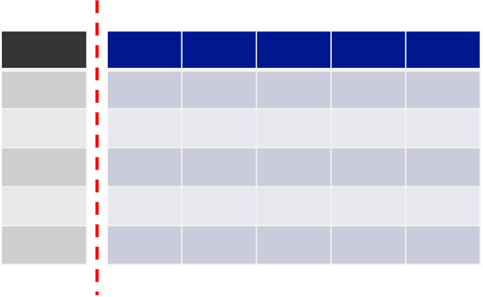

In [3]:
# 1) 먼저 x와 y로 분할
target = 'Sales'
x = data.drop(target, axis=1) # .drop(   , inplace = True)
y = data.loc[:, target] # : 처음부터 끝까지  data['Sales']

In [4]:
x.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [5]:
y.head()

,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


2) train, validation, test로 분할

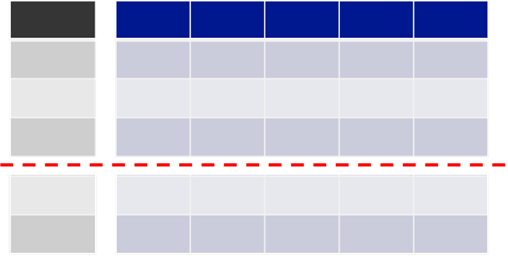

In [7]:
# 2) 전체에서 train : test = 7 : 3 으로 나눕니다.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

## 3.학습

* 필요한 함수들 불러오기

In [6]:
# 알고리즘 불러오기 : 선형회귀
from sklearn.linear_model import LinearRegression

# 회귀 모델 평가 함수 불러오기
from sklearn.metrics import mean_absolute_error #평균 오차 의미

* 모델 선언하기

In [8]:
# 모델 선언 : 알고리즘을 어떻게 사용할지 설정
model = LinearRegression()

* 학습

In [9]:
# 학습 : .fit   ==> 학습은 x와 y의 패턴을 찾아내는 과정입니다.
model.fit(x_train, y_train)

LinearRegression()

## 4.예측
* 학습의 결과 모델이 만들어 집니다.
* 모델이 얼마나 정확한지 검증해 봅시다.

In [10]:
pred = model.predict(x_test)

In [14]:
pred

array([21.66985861, 12.42267395, 14.21474552, 15.70842309, 19.54073375,
       12.13053467, 21.84612946, 15.76290232, 20.3625003 , 21.25572076,
       19.4753971 , 15.77100933, 18.7055461 ,  4.50182847,  6.79358846,
        7.75986625, 18.69361914, 12.03439128,  8.22416456, 15.54862235,
       10.57409109, 18.55850157, 14.03286989, 11.75075734,  8.96005816,
        9.96870425,  5.71716519, 13.19548734,  5.20015446, 17.31506661,
       17.16464282,  7.56478996, 17.8266821 , 12.69377045, 18.71567425,
        4.43328896, 25.03493723, 17.07718993, 16.66505833, 15.53366317,
        4.46206275,  8.11550245,  9.15235258, 12.44471974, 11.9427537 ,
       10.46847914,  7.93023297, 16.41942253,  8.58403052, 23.52125469,
       19.70049285,  9.28117097, 17.0790144 , 12.43763747, 13.70427167,
       20.4871178 , 18.90625458, 16.51757931, 12.75064358, 12.11996496])

## 5.평가

In [15]:
# 평균 오차
mean_absolute_error(y_test, pred)

1.376716761646439

In [22]:
model.fit(x_train,y_train)

LinearRegression()

# 복습문제1 : Diamond Price 예측
* 위 코드를 보면서 그대로 따라해보기
* copy & paste 보다는 보면서 따라 코딩하기를 권장합니다.

## 1.데이터 로딩

In [23]:
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/diamonds.csv'
data = pd.read_csv(path)
data = data.sample(2000, random_state=20)
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
20244,1.52,Fair,H,VS2,62.1,66.0,8674,7.33,7.13,4.50
45013,0.54,Premium,G,VS2,62.0,58.0,1637,5.21,5.18,3.22
53351,0.70,Premium,E,VS2,62.0,60.0,2657,5.70,5.59,3.50
47212,0.59,Ideal,E,VS2,62.2,58.0,1838,5.35,5.39,3.34
1460,0.86,Premium,F,SI2,61.8,58.0,2980,6.12,6.15,3.79


## 2.데이터 전처리

* 분할1 : x, y

In [24]:
target = 'price'
x = data.drop(target, axis=1)
y = data.loc[:, target]

* 가변수화

In [25]:
col_cat = ['cut','color','clarity']
x = pd.get_dummies(x, columns = col_cat, drop_first = True)

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

## 3.학습

In [35]:

from sklearn.linear_model import LinearRegression


from sklearn.metrics import mean_absolute_error #평균 오차 의미

In [36]:
model = LinearRegression()

In [37]:
model.fit(x_train, y_train)

LinearRegression()

## 4.예측


In [38]:
pred = model.predict(x_test)
pred

array([ 1.07072045e+03, -4.84840891e+02,  1.00232828e+04,  4.58403229e+03,
        7.30775114e+03, -1.08486300e+02,  3.92636009e+03,  4.10697009e+03,
        1.11560156e+03,  2.90107219e+03,  1.25279057e+04,  1.30690059e+03,
       -5.51411602e+02,  7.89534357e+03,  2.49006946e+03,  5.13274696e+03,
       -5.97667743e+02,  1.82713583e+03,  2.87073093e+03,  4.65274167e+02,
        7.00073013e+02,  7.17488077e+02,  8.90019963e+02,  1.32310890e+03,
        1.45985252e+04, -3.22121538e+01,  3.56241692e+03,  1.54356852e+03,
        2.49649033e+03,  1.08500753e+04,  6.72291701e+02,  2.27074896e+03,
        4.88111549e+03,  1.50506756e+04,  9.58356070e+02,  9.10721116e+02,
        2.24391183e+03,  6.72764115e+03,  6.04760584e+03,  1.08077866e+03,
        1.32268824e+03,  5.66879136e+03,  3.28910329e+03,  2.31694054e+03,
        7.48437227e+03,  6.36829934e+03,  2.88072422e+03,  1.00034517e+04,
        8.21004089e+03,  1.28182089e+03,  5.64755161e+03,  4.53776247e+03,
        7.49967615e+03,  

## 5.평가

In [39]:
mean_absolute_error(y_test, pred)

687.3354239465721

# 복습문제2 : 보스턴시 타운별 집값 예측
* 위 코드를 보면서 그대로 따라해보기
* copy & paste 보다는 보면서 따라 코딩하기를 권장합니다.

## 1.데이터 로딩

In [40]:
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/boston.csv'
cols = ['crim','indus','chas','nox','rm', 'dis', 'tax','ptratio','lstat','medv']
data = pd.read_csv(path, usecols = cols)
data.head()

,crim,indus,chas,nox,rm,dis,tax,ptratio,lstat,medv
0,0.00632,2.31,0,0.538,6.575,4.0900,296,15.3,4.98,24.0
1,0.02731,7.07,0,0.469,6.421,4.9671,242,17.8,9.14,21.6
2,0.02729,7.07,0,0.469,7.185,4.9671,242,17.8,4.03,34.7
3,0.03237,2.18,0,0.458,6.998,6.0622,222,18.7,2.94,33.4
4,0.06905,2.18,0,0.458,7.147,6.0622,222,18.7,5.33,36.2


## 2.데이터 전처리

In [41]:
# 1) 먼저 x와 y로 분할
target = 'medv'
x = data.drop(target, axis=1)
y = data.loc[:, target]

In [42]:
# 2) 전체에서 train : test = 7 : 3 으로 나눕니다.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

## 3.학습

In [44]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error

In [45]:
model = LinearRegression()

In [46]:
model.fit(x_train,y_train)

LinearRegression()

## 4.예측


In [47]:
pred = model.predict(x_test)
pred

array([38.06615597, 20.34130203, 13.50759699, 21.65096893, 14.37340702,
       20.15387889, 23.48505921, 32.66873759, 24.45487211, 35.19246162,
       13.59867095, 40.89798863, 34.73542433, 21.38618152, 13.2206682 ,
       17.92299124, 25.22400833, 27.30337649, 17.4528391 , 15.23025144,
       -1.58823776, 17.1303101 , 35.8226912 , 33.31715735, 30.31054212,
       33.71861199, 16.62441658, 24.15216476, 22.05454659, 21.76221539,
       31.20988051, 11.12141218, 21.64522714, 37.83803294, 21.50474755,
       26.21224582, 38.83828226, 32.03610439, 37.31466883, 25.96822259,
       36.21260767,  3.5391751 , 36.03740533, 13.73287967, 17.6657227 ,
       14.86675654, 12.40825916, 15.57311722, 16.64781753, 23.17165843,
       15.35752101, 37.48381603, 11.33565002, 34.00139543, 24.12562516,
       23.94152595, 17.98377514, 24.02154519, 27.09128282, 35.44637093,
       20.52666391, 19.08223078, 24.98025827, 21.77363793, 25.58369381,
       37.75361879, 17.61017683, 19.67652156, 23.17159954, 14.81

## 5.평가

In [48]:
mean_absolute_error(y_test, pred)

3.3579056521652917